# **Tugas 3 : Singular Value Decomposition (SVD)**

## Aplikasi SVD pada Kompresi Gambar Berwarna

Di bawah ini adalah kode untuk mengompresi gambar menggunakan metode SVD. Perhatikan penggunaan path berkas gambar yang tepat dan pemisahan channel warna (R, G, B).

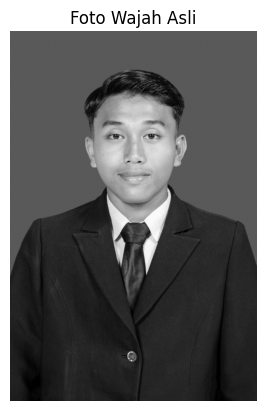

In [1]:
# import cv2
import numpy as np
import matplotlib.pyplot as plt

# ✅ Ganti 'abdul_hadi_marzuqi.jpeg' dengan nama file foto wajah lo
# Letakkan foto di folder yang sama dengan notebook ini
from PIL import Image
image = np.array(Image.open('abdul_hadi_marzuqi.jpeg').convert('L'))

# Kalau cv2 tidak ada, pakai ini sebagai gantinya:
# from PIL import Image
# image = np.array(Image.open('abdul_hadi_marzuqi.jpeg').convert('L'))

plt.imshow(image, cmap='gray')
plt.title('Foto Wajah Asli')
plt.axis('off')
plt.show()

In [2]:
U, S, Vt = np.linalg.svd(image, full_matrices=False)
print(f"Shape U : {U.shape}")
print(f"Shape S : {S.shape}")
print(f"Shape Vt: {Vt.shape}")
print(f"\n10 singular value terbesar : {S[:10].astype(int)}")
print(f"10 singular value terkecil : {S[-10:].round(2)}")

Shape U : (1600, 1066)
Shape S : (1066,)
Shape Vt: (1066, 1066)

10 singular value terbesar : [106541  21623  13642  11676  10390   6826   5502   4990   4515   4297]
10 singular value terkecil : [1.6  1.56 1.52 1.5  1.47 1.44 1.35 1.31 1.24 1.17]


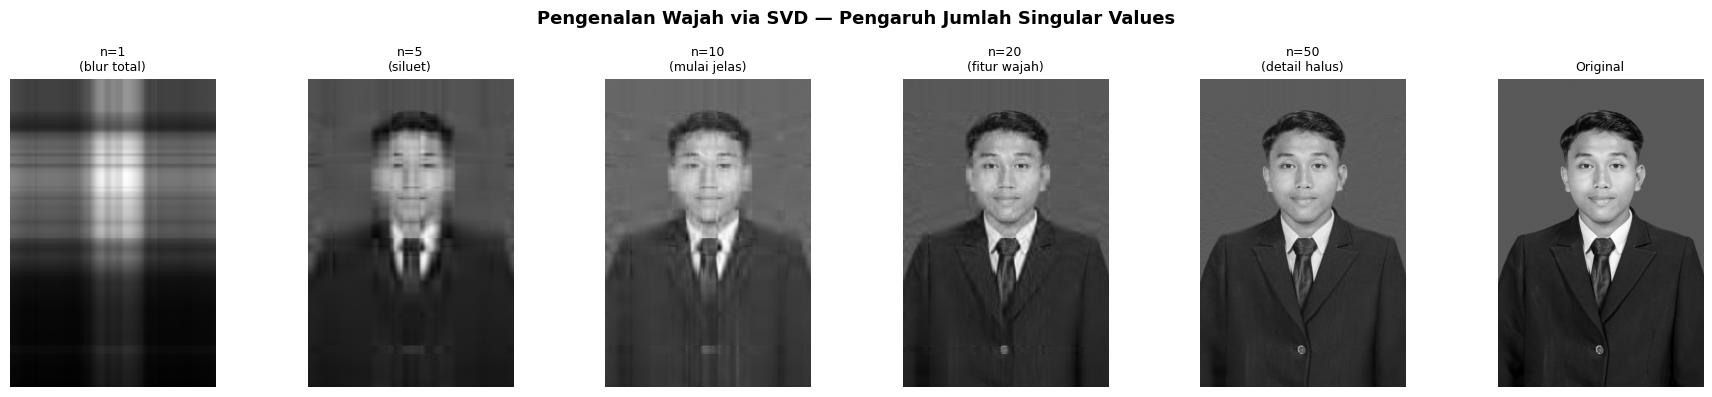

In [3]:
fig, axes = plt.subplots(1, 6, figsize=(18, 4))
fig.suptitle('Pengenalan Wajah via SVD — Pengaruh Jumlah Singular Values',
             fontweight='bold', fontsize=13)

n_values = [1, 5, 10, 20, 50, len(S)]
labels   = [
    'n=1\n(blur total)',
    'n=5\n(siluet)',
    'n=10\n(mulai jelas)',
    'n=20\n(fitur wajah)',
    'n=50\n(detail halus)',
    'Original'
]

for ax, n, label in zip(axes, n_values, labels):
    recon = np.array(U[:, :n]) @ np.diag(S[:n]) @ np.array(Vt[:n, :])
    ax.imshow(recon, cmap='gray')
    ax.set_title(label, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
print("=" * 45)
print(" Analisis Kompresi Wajah")
print("=" * 45)
print(f"{'n':>6} | {'Rasio Kompresi':>14} | {'Info Tersimpan':>14}")
print("-" * 45)

total_energy = np.sum(S**2)
m, k = image.shape

for n in [1, 5, 10, 20, 50, 100, 200]:
    if n > len(S):
        break
    rasio  = (m * k) / (n * (m + k + 1))
    energy = np.sum(S[:n]**2) / total_energy * 100
    print(f"{n:>6} | {rasio:>13.1f}x | {energy:>13.2f}%")

print("-" * 45)
print(f"{'Original':>6} | {'1.0x':>14} | {'100.00%':>14}")

 Analisis Kompresi Wajah
     n | Rasio Kompresi | Info Tersimpan
---------------------------------------------
     1 |         639.5x |         90.28%
     5 |         127.9x |         97.42%
    10 |          64.0x |         98.54%
    20 |          32.0x |         99.27%
    50 |          12.8x |         99.73%
   100 |           6.4x |         99.88%
   200 |           3.2x |         99.96%
---------------------------------------------
Original |           1.0x |        100.00%
